# CREATE SUPPLEMENTARY FIGURE 4B
## last updated: 06.12.26

In [2]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt

/Users/spribus/anaconda3/lib/python3.10/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [4]:
DELLY_df = pd.read_csv("full_tool_testing/DELLY_ic_cycle_data_table_with_conf.csv")
GRIDSS_df = pd.read_csv("full_tool_testing/GRIDSS_ic_cycle_data_table_with_conf.csv")
MANTA_df = pd.read_csv("full_tool_testing/MANTA_ic_cycle_data_table_with_conf.csv")
SVABA_df = pd.read_csv("full_tool_testing/SVABA_ic_cycle_data_table_with_conf.csv")
og_df = pd.read_csv("full_tool_testing/ic_cycle_data_w_conf.csv")

In [10]:
iterations = {
    "Delly": DELLY_df,
    "GRIDSS": GRIDSS_df,
    "MANTA": MANTA_df,
    "SvABA": SVABA_df,
}

In [11]:
key_cols = ["Sample", "Amplicon", "Cycle"]

results = []

for name, df in iterations.items():

    merged = og_df[
        key_cols + ["Confidence"]
    ].merge(
        df[key_cols + ["Confidence"]],
        on=key_cols,
        suffixes=("_orig", "_iter"),
        how="inner"
    )

    n_total = len(merged)

    n_changed = (
        merged["Confidence_orig"]
        != merged["Confidence_iter"]
    ).sum()

    n_same = n_total - n_changed

    results.append({
        "Iteration": name,
        "Stable": n_same / n_total,
        "Changed": n_changed / n_total
    })

results_df = pd.DataFrame(results)

In [12]:
results_df

,Iteration,Stable,Changed
0,Delly,0.860182,0.139818
1,GRIDSS,0.964539,0.035461
2,MANTA,0.800405,0.199595
3,SvABA,0.900709,0.099291


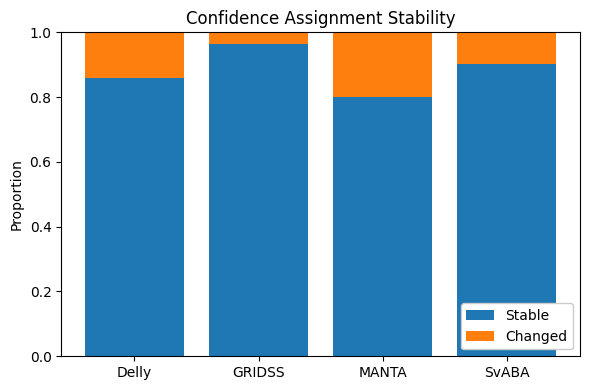

In [14]:
fig, ax = plt.subplots(figsize=(6,4))

ax.bar(
    results_df["Iteration"],
    results_df["Stable"],
    label="Stable"
)

ax.bar(
    results_df["Iteration"],
    results_df["Changed"],
    bottom=results_df["Stable"],
    label="Changed"
)

ax.set_ylabel("Proportion")
ax.set_ylim(0, 1)
ax.set_title("Confidence Assignment Stability")
ax.legend(
    loc="lower right",
    frameon=True,
    framealpha=1.0  # fully opaque
)

plt.tight_layout()
plt.show()